# 모의고사 02 - 배송 소요시간 예측

In [97]:
# 라이브러리 임포트
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [98]:
# 데이터 불러오기
delivery_df = pd.read_csv('C:/juehyeon/aice_test/materials/datasets/delivery_time.csv')
delivery_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_amount       1164 non-null   float64
 1   num_items          1200 non-null   int64  
 2   distance_km        1200 non-null   float64
 3   rider_experience   1200 non-null   object 
 4   weather            1200 non-null   object 
 5   order_time         1200 non-null   object 
 6   promotion_applied  1200 non-null   object 
 7   delivery_time_min  1200 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 75.1+ KB


In [99]:
delivery_df.head()

,order_amount,num_items,distance_km,rider_experience,weather,order_time,promotion_applied,delivery_time_min
0,30.18,5,6.49,medium,rain,afternoon,N,26.5
1,33.76,1,9.17,low,fog,morning,N,26.4
2,97.96,2,11.80,low,fog,night,Y,37.1
3,99.36,5,10.67,high,snow,evening,N,45.0
4,99.55,5,5.81,high,snow,night,Y,20.0


<Axes: xlabel='weather', ylabel='delivery_time_min'>

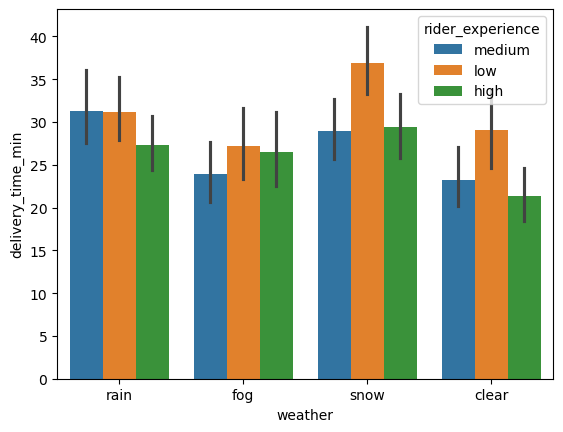

In [100]:
# 데이터 시각화
sns.barplot(data = delivery_df, x = 'weather', y = 'delivery_time_min', hue = 'rider_experience')

데이터 해석: snow 조건에서는 숙련도 간 차이가 가장 뚜렷하고, low 숙련도 라이더의 배송 시간이 다른 조건에 비해 가장 김

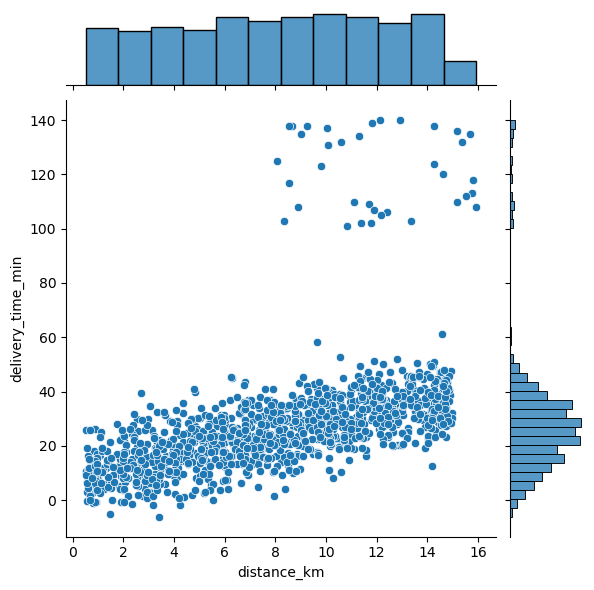

In [101]:
## jointplot 이용하여 배달시간 , 배달거리 분석
sns.jointplot(data = delivery_df, x = 'distance_km', y = 'delivery_time_min')

In [102]:
# 이상치 제거 
del_df = delivery_df[delivery_df.delivery_time_min < 100]

In [103]:
# 이상치 (음수 제거)
(del_df['delivery_time_min'] < 0 ).sum() # 이상치 제거 전 

np.int64(11)

In [104]:
# 이상치 확인 
outliers = del_df[del_df['delivery_time_min'] < 0].index

In [105]:
del_df = del_df.drop(outliers, axis = 0)

In [106]:
# 이상치 제거 후
(del_df['delivery_time_min'] < 0).sum()

np.int64(0)

In [107]:
# 인덱스 재정렬하기
del_df.reset_index(drop = True, inplace = True)

In [108]:
# 불필요한 컬럼 삭제 
cols = ['order_amount', 'num_items']
del_df = del_df.drop(columns = cols, axis = 1)

In [109]:
del_df.head() # 확인하기

,distance_km,rider_experience,weather,order_time,promotion_applied,delivery_time_min
0,6.49,medium,rain,afternoon,N,26.5
1,9.17,low,fog,morning,N,26.4
2,11.80,low,fog,night,Y,37.1
3,10.67,high,snow,evening,N,45.0
4,5.81,high,snow,night,Y,20.0


In [110]:
# 범주형 변수 원 핫 인코딩하기
cat_col = ['rider_experience', 'weather', 'order_time']
del_df = pd.get_dummies(data = del_df, columns = cat_col, drop_first = True) 
del_df.head()

,distance_km,promotion_applied,delivery_time_min,rider_experience_low,rider_experience_medium,weather_fog,weather_rain,weather_snow,order_time_evening,order_time_morning,order_time_night
0,6.49,N,26.5,False,True,False,True,False,False,False,False
1,9.17,N,26.4,True,False,True,False,False,False,True,False
2,11.80,Y,37.1,True,False,True,False,False,False,False,True
3,10.67,N,45.0,False,False,False,False,True,True,False,False
4,5.81,Y,20.0,False,False,False,False,True,False,False,True


In [111]:
# 이진 범수형 변수 Label Encoding
## 라이브러리 임포트
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
del_df['promotion_applied'] = le.fit_transform(del_df['promotion_applied'])
del_df.head()

,distance_km,promotion_applied,delivery_time_min,rider_experience_low,rider_experience_medium,weather_fog,weather_rain,weather_snow,order_time_evening,order_time_morning,order_time_night
0,6.49,0,26.5,False,True,False,True,False,False,False,False
1,9.17,0,26.4,True,False,True,False,False,False,True,False
2,11.80,1,37.1,True,False,True,False,False,False,False,True
3,10.67,0,45.0,False,False,False,False,True,True,False,False
4,5.81,1,20.0,False,False,False,False,True,False,False,True


In [112]:
# 데이터셋 분리
## 라이브러리 임포트
from sklearn.model_selection import train_test_split

In [113]:
## 데이터셋

In [114]:
X = del_df.drop(columns = 'delivery_time_min')
y = del_df['delivery_time_min']

In [115]:
## 데이터셋 분리
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state = 42, test_size = 0.2)

In [116]:
# 데이터 스케일링
## 라이브러리 임포트
from sklearn.preprocessing import StandardScaler
## 모델 객체 생성
ss = StandardScaler()
## 데이터 학습
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_valid)

In [117]:
# 선형 회귀 모델 생성 및 학습
## 라이브러리 임포트 
from sklearn.linear_model import LinearRegression
## 모델 객체 생성
lr = LinearRegression()
## 학습
lr.fit(X_train, y_train) 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [118]:
# 랜덤포레스트 모델 생성 및 학습
## 라이브러리 임포트 
from sklearn.ensemble import RandomForestRegressor
## 모델 객체 생성
rfr = RandomForestRegressor(n_estimators = 100, max_depth = 10, random_state = 42)

In [119]:
rfr.fit(X_train, y_train) 

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [120]:
# 딥러닝 모델 설계 및 학습
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, BatchNormalization
tf.random.set_seed(42)

In [121]:
dl = Sequential([
    Input(shape = (X_train.shape[1],)),
    Dense(64, activation = 'relu'),
    BatchNormalization(),
    Dense(32, activation = 'relu'),
    BatchNormalization(),
    Dense(16, activation = 'relu'),
    Dense(1, activation = 'linear')
])

In [122]:
## 모델 컴파일 
dl.compile(
    optimizer = 'adam',
    loss = 'mean_squared_error', 
    metrics = ['mean_absolute_error']
) 

In [123]:
## 모델 학습 
dl.fit(
    X_train,
    y_train,
    epochs = 50,
    batch_size = 128
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 782.1071 - mean_absolute_error: 25.5960
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 755.9717 - mean_absolute_error: 25.1694 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 734.5388 - mean_absolute_error: 24.8037 
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 715.4576 - mean_absolute_error: 24.4665 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 696.4499 - mean_absolute_error: 24.1296 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 676.8774 - mean_absolute_error: 23.7826 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 656.5679 - mean_absolute_error: 23.4201 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 635.7137 - mean_absolute_error: 23.0446 
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 614.1675 - mean_absolute_error: 22.6515 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 591.5894 - mean_absolute_error: 22.2367 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━

In [124]:
# Early Stopping, Model Check point 설정
## 라이브러리 임포트
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True
)
model_checkpoint = ModelCheckpoint(
    filepath = 'best_model.h5',
    monitor = 'val_loss',
    save_best_only = True,
    verbose = 1
)
dl.fit(
    X_train,y_train,
    epochs = 50,
    batch_size = 128,
    validation_data = (X_test, y_valid),
    callbacks = [early_stopping, model_checkpoint]
)

Epoch 1/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 48.1705 - mean_absolute_error: 5.5124
Epoch 1: val_loss improved from None to 67.06219, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 44.0255 - mean_absolute_error: 5.2371 - val_loss: 67.0622 - val_mean_absolute_error: 6.5028
Epoch 2/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 47.2171 - mean_absolute_error: 5.4556
Epoch 2: val_loss improved from 67.06219 to 66.77785, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 43.3087 - mean_absolute_error: 5.1926 - val_loss: 66.7778 - val_mean_absolute_error: 6.4895
Epoch 3/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 46.6939 - mean_absolute_error: 5.4229
Epoch 3: val_loss improved from 66.77785 to 66.30428, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 42.7075 - mean_absolute_error: 5.1549 - val_loss: 66.3043 - val_mean_absolute_error: 6.4663
Epoch 4/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 46.2367 - mean_absolute_error: 5.3969
Epoch 4: val_loss improved from 66.30428 to 65.79910, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 42.1990 - mean_absolute_error: 5.1240 - val_loss: 65.7991 - val_mean_absolute_error: 6.4412
Epoch 5/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 45.8464 - mean_absolute_error: 5.3789
Epoch 5: val_loss improved from 65.79910 to 65.30030, saving model to best_model.h5


...


Epoch 21: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 37.4050 - mean_absolute_error: 4.8435 - val_loss: 60.1598 - val_mean_absolute_error: 6.1094
Epoch 22/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 40.3160 - mean_absolute_error: 5.1729
Epoch 22: val_loss improved from 60.15978 to 60.08850, saving model to best_model.h5



Epoch 22: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 37.1903 - mean_absolute_error: 4.8297 - val_loss: 60.0885 - val_mean_absolute_error: 6.1042
Epoch 23/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 40.0591 - mean_absolute_error: 5.1648
Epoch 23: val_loss improved from 60.08850 to 60.05971, saving model to best_model.h5



Epoch 23: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 36.9866 - mean_absolute_error: 4.8159 - val_loss: 60.0597 - val_mean_absolute_error: 6.1009
Epoch 24/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 39.8278 - mean_absolute_error: 5.1554
Epoch 24: val_loss improved from 60.05971 to 60.03806, saving model to best_model.h5



Epoch 24: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 36.7873 - mean_absolute_error: 4.8036 - val_loss: 60.0381 - val_mean_absolute_error: 6.0959
Epoch 25/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 39.6242 - mean_absolute_error: 5.1479
Epoch 25: val_loss improved from 60.03806 to 59.95929, saving model to best_model.h5



Epoch 25: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 36.5858 - mean_absolute_error: 4.7939 - val_loss: 59.9593 - val_mean_absolute_error: 6.0869
Epoch 26/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 39.3977 - mean_absolute_error: 5.1414
Epoch 26: val_loss did not improve from 59.95929
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 36.3716 - mean_absolute_error: 4.7816 - val_loss: 60.0192 - val_mean_absolute_error: 6.0845
Epoch 27/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 39.2141 - mean_absolute_error: 5.1360
Epoch 27: val_loss did not improve from 59.95929
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 36.1825 - mean_absolute_error: 4.7673 - val_loss: 60.0698 - val_mean_absolute_error: 6.0864
Epoch 28/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 39.0161 - mean_absolute_error: 5.1267
Epoch 28: val_loss did not improve from 59.95929
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 35.9674 - mean_absolute_error: 4.7547 - val_loss: 60.08